   sepal_length  sepal_width  petal_length  petal_width      species
1           5.1          3.5           1.4          0.2  Iris-setosa
2           4.9          3.0           1.4          0.2  Iris-setosa
3           4.7          3.2           1.3          0.2  Iris-setosa
4           4.6          3.1           1.5          0.2  Iris-setosa
5           5.0          3.6           1.4          0.2  Iris-setosa
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max

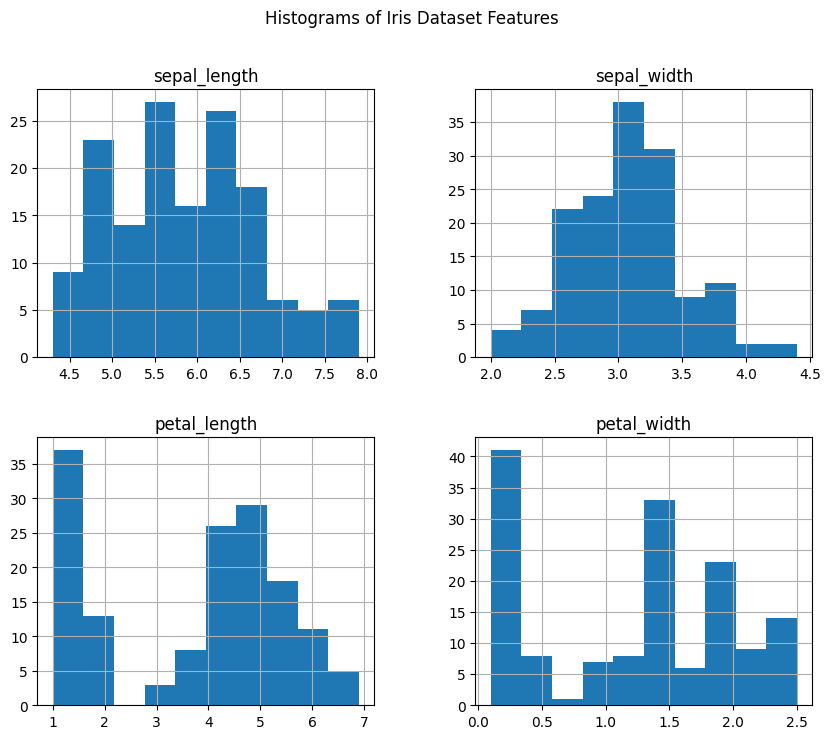

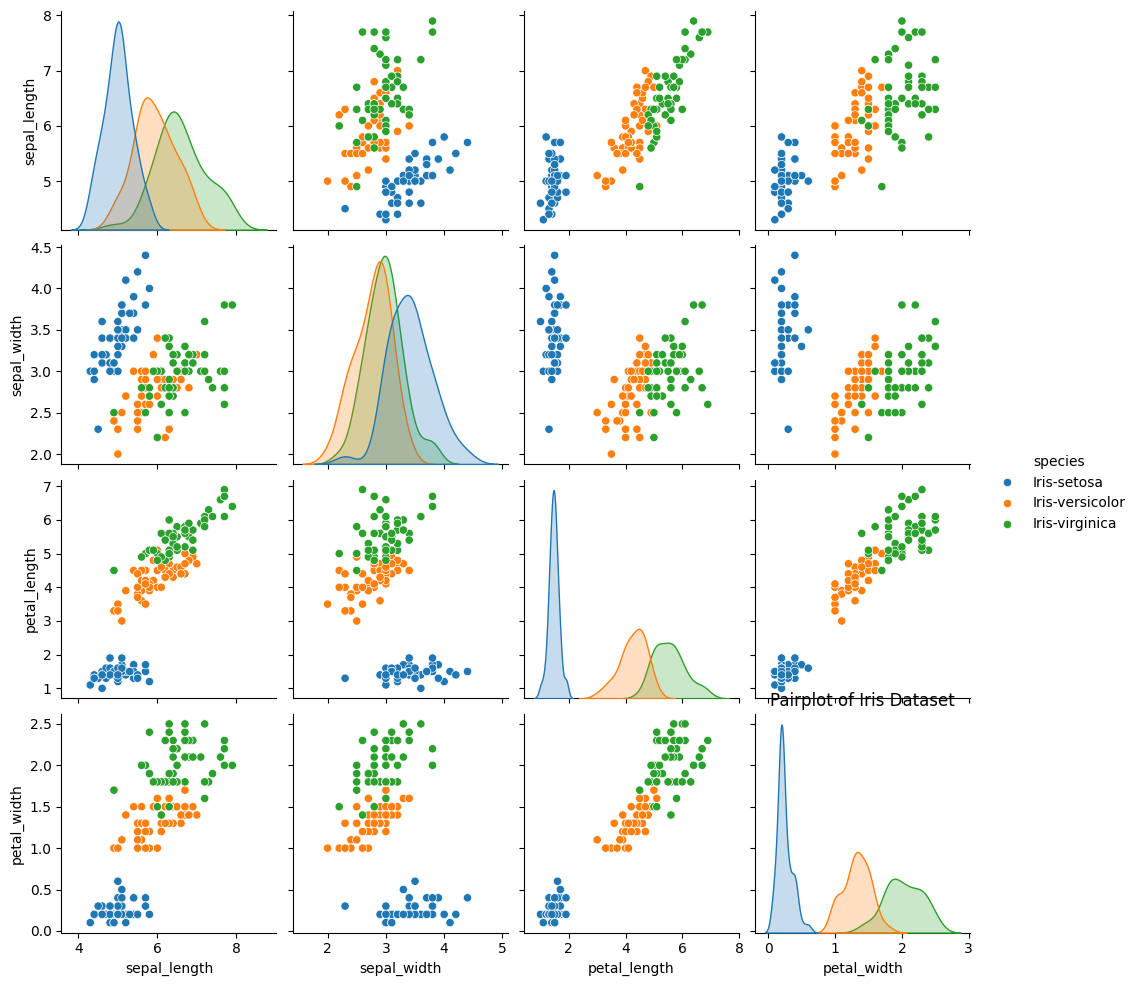

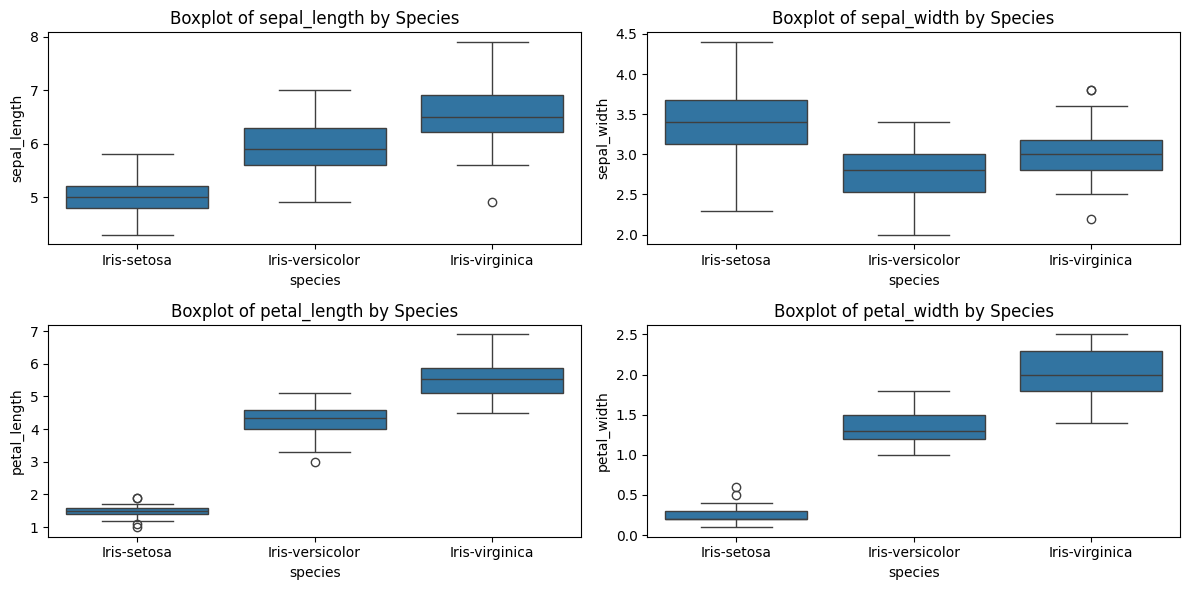

Scaled Iris Data:
   sepal_length  sepal_width  petal_length  petal_width  species
0     -0.900681     1.032057     -1.341272    -1.312977      NaN
1     -1.143017    -0.124958     -1.341272    -1.312977      0.0
2     -1.385353     0.337848     -1.398138    -1.312977      0.0
3     -1.506521     0.106445     -1.284407    -1.312977      0.0
4     -1.021849     1.263460     -1.341272    -1.312977      0.0

Binarized Iris Data:
   sepal_length  sepal_width  petal_length  petal_width  species
0           0.0          1.0           0.0          0.0      NaN
1           0.0          0.0           0.0          0.0      0.0
2           0.0          0.0           0.0          0.0      0.0
3           0.0          0.0           0.0          0.0      0.0
4           0.0          1.0           0.0          0.0      0.0


In [8]:
# Practical No. 1
# Aim: Data Pre-processing and Exploration.

# Step 1: Load the Iris Dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
iris_data = pd.read_csv("C:/Users/Lenovo/Downloads/datasets/iris.csv", header=None, names=column_names, skiprows=1)
print(iris_data.head())

# Step 2: Handle Missing Values and Inconsistent Formatting
print(iris_data.isnull().sum())

# Step 3: Calculate Descriptive Summary Statistics
print(iris_data.describe())

# Step 4: Create Visualizations
iris_data.hist(bins=10, figsize=(10, 8))
plt.suptitle('Histograms of Iris Dataset Features')
plt.show()
sns.pairplot(iris_data, hue='species')
plt.title('Pairplot of Iris Dataset')
plt.show()
plt.figure(figsize=(12, 6))
for i, feature in enumerate(column_names[:-1]):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='species', y=feature, data=iris_data)
    plt.title(f'Boxplot of {feature} by Species')
plt.tight_layout()
plt.show()

# Step 5: Pre-processing Routines
from sklearn.preprocessing import LabelEncoder, StandardScaler, Binarizer
label_encoder = LabelEncoder()
iris_data['species'] = label_encoder.fit_transform(iris_data['species'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(iris_data.iloc[:, :-1]) # Exclude target variable
scaled_iris_data = pd.DataFrame(scaled_features, columns=column_names[:-1])
scaled_iris_data['species'] = iris_data['species']
binarizer = Binarizer(threshold=0.5)
binarized_features = binarizer.fit_transform(scaled_iris_data.iloc[:, :-1])
binarized_iris_data = pd.DataFrame(binarized_features, columns=column_names[:-1])
binarized_iris_data['species'] = scaled_iris_data['species']
print("Scaled Iris Data:")
print(scaled_iris_data.head())
print("\nBinarized Iris Data:")
print(binarized_iris_data.head())
